In [2]:
# ============================================================
# CHECK GPU TENSORFLOW
# ============================================================

import tensorflow as tf

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices('GPU')

print("Available GPUs:", gpus)

if gpus:
    print("GPU DETECTED")
else:
    print("GPU NOT DETECTED")

TensorFlow version: 2.16.1
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU DETECTED


In [ ]:
# ============================================================
# Cell 1 - Library dan konfigurasi utama berbasis NPZ
# ============================================================

from pathlib import Path
import os
import json
import random
import pickle
import itertools
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

warnings.filterwarnings("ignore")

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kwargs):
        return x


# ============================================================
# SEED CONFIG
# ============================================================

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# DATA CONFIG
# ============================================================

N_TARGET = 369
WINDOW_SIZE = 20
STRIDE = 2

N_FOLDER_NAME = f"N{N_TARGET:04d}"

NPZ_ROOT = Path("/media/spell/Spell-lab/Lidar/G.NPZ Dataset") / N_FOLDER_NAME
TRAINING_OUT_ROOT = Path("/media/spell/Spell-lab/Lidar/F.Training Results")

RECOVERED_BEST_CONFIG_PATH = TRAINING_OUT_ROOT / "best_hpo_config_recovered.json"

TRIAL_NAME = f"DGCNN_GRU_N{N_TARGET:04d}_T{WINDOW_SIZE:03d}_S{STRIDE:03d}"
TRIAL_ROOT = TRAINING_OUT_ROOT / TRIAL_NAME


# ============================================================
# OUTPUT FOLDERS
# ============================================================

MODELS_DIR = TRIAL_ROOT / "models"
SCALERS_DIR = TRIAL_ROOT / "scalers"
CONFIGS_DIR = TRIAL_ROOT / "configs"
HPO_DIR = TRIAL_ROOT / "hpo"
FINAL_DIR = TRIAL_ROOT / "final"
FIGURES_DIR = TRIAL_ROOT / "figures"
PREDICTIONS_DIR = TRIAL_ROOT / "predictions"
REPORTS_DIR = TRIAL_ROOT / "reports"

for d in [
    TRIAL_ROOT, MODELS_DIR, SCALERS_DIR, CONFIGS_DIR,
    HPO_DIR, FINAL_DIR, FIGURES_DIR, PREDICTIONS_DIR, REPORTS_DIR
]:
    d.mkdir(parents=True, exist_ok=True)


# ============================================================
# DATASET CONFIG
# ============================================================

ACTIVITIES = ["Bungkuk", "Duduk", "Jongkok", "Jatuh"]

DEV_SUBJECTS = [
    "Adelia", "Afi", "Aswangga", "Bustan",
    "Dilia", "Eldivo", "Fathir", "Lina",
    "Manda", "Miftah", "Teguh", "Tsamara",
]

TEST_SUBJECTS = ["Kanaya", "Naila", "Nana", "Rega", "Zaira"]

TEST_ROOM_FOR_MODEL_EVAL = "Controlled Room"

FILE_IDS = list(range(1, 10))

FEATURE_COLUMNS = ["X_corr", "Y_corr", "Z_level"]

NPZ_COLUMNS = [
    "Timestamp",
    "X",
    "Y",
    "Z",
    "X_corr",
    "Y_corr",
    "Z_corr",
    "Z_level",
    "Reflectivity",
]


# ============================================================
# LABEL CONFIG
# ============================================================

LABEL_MAP = {
    "Bungkuk": 0,
    "Duduk": 0,
    "Jongkok": 0,
    "Jatuh": 1,
}

CLASS_NAMES = ["Non-Fall", "Fall"]


# ============================================================
# TRAINING CONFIG
# ============================================================

BATCH_SIZE = 4

CV_SPLITS = 4
RANDOM_SEARCH_TRIALS = 0

MAX_EPOCHS_HPO = 0
EARLY_STOP_PATIENCE_HPO = 0

MAX_EPOCHS_FINAL = 100
EARLY_STOP_PATIENCE_FINAL = 15

VERBOSE = 1

FINAL_VAL_SPLITS = 6  # 12 subjects -> approx 10 train, 2 val


# ============================================================
# HPO CONFIG
# ============================================================

HPO_SPACE = {
    "knn_k": [10, 15, 20],
    "learning_rate": [5e-4, 1e-4, 5e-5],
    "l2_weight": [1e-5, 1e-4],
    "dropout_temporal": [0.2, 0.3],
    "dropout_classifier": [0.3, 0.4],
}


# ============================================================
# BEHAVIOR CONFIG
# ============================================================

RUN_HPO = False
USE_EXISTING_BEST_CONFIG_IF_AVAILABLE = False
USE_RECOVERED_BEST_CONFIG = True

REQUIRE_CONSECUTIVE_FRAMES = True

BEST_MODEL_PATH = MODELS_DIR / "best_model.keras"
SCALER_PATH = SCALERS_DIR / "scaler.pkl"
BEST_WEIGHTS_PATH = MODELS_DIR / "best_model.weights.h5"


print("===== TRAINING CONFIG - NPZ MODE =====")
print(f"NPZ root        : {NPZ_ROOT}")
print(f"Trial root      : {TRIAL_ROOT}")
print(f"Recovered config: {RECOVERED_BEST_CONFIG_PATH}")
print(f"N_TARGET        : {N_TARGET}")
print(f"WINDOW_SIZE     : {WINDOW_SIZE}")
print(f"STRIDE          : {STRIDE}")
print(f"BATCH_SIZE      : {BATCH_SIZE}")
print(f"RUN_HPO         : {RUN_HPO}")
print(f"Framework       : TensorFlow {tf.__version__}")

if not NPZ_ROOT.exists():
    raise FileNotFoundError(f"NPZ root tidak ditemukan: {NPZ_ROOT}")

if USE_RECOVERED_BEST_CONFIG and not RECOVERED_BEST_CONFIG_PATH.exists():
    raise FileNotFoundError(f"Recovered best config tidak ditemukan: {RECOVERED_BEST_CONFIG_PATH}")

===== TRAINING CONFIG - NPZ MODE =====
NPZ root        : /media/spell/Spell-lab/Lidar/G.NPZ Dataset/N0369
Trial root      : /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002
Recovered config: /media/spell/Spell-lab/Lidar/F.Training Results/best_hpo_config_recovered.json
N_TARGET        : 369
WINDOW_SIZE     : 20
STRIDE          : 2
BATCH_SIZE      : 4
RUN_HPO         : False
Framework       : TensorFlow 2.16.1


In [4]:
# ============================================================
# Cell 2 - Simpan konfigurasi training berbasis NPZ
# ============================================================

training_config = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "seed": SEED,
    "npz_root": str(NPZ_ROOT),
    "training_out_root": str(TRAINING_OUT_ROOT),
    "trial_name": TRIAL_NAME,
    "trial_root": str(TRIAL_ROOT),
    "recovered_best_config_path": str(RECOVERED_BEST_CONFIG_PATH),
    "n_target": N_TARGET,
    "window_size": WINDOW_SIZE,
    "stride": STRIDE,
    "feature_columns": FEATURE_COLUMNS,
    "npz_columns": NPZ_COLUMNS,
    "label_map": LABEL_MAP,
    "class_names": CLASS_NAMES,
    "batch_size": BATCH_SIZE,
    "cv_splits": CV_SPLITS,
    "random_search_trials": RANDOM_SEARCH_TRIALS,
    "max_epochs_hpo": MAX_EPOCHS_HPO,
    "early_stop_patience_hpo": EARLY_STOP_PATIENCE_HPO,
    "max_epochs_final": MAX_EPOCHS_FINAL,
    "early_stop_patience_final": EARLY_STOP_PATIENCE_FINAL,
    "hpo_space": HPO_SPACE,
    "run_hpo": RUN_HPO,
    "use_recovered_best_config": USE_RECOVERED_BEST_CONFIG,
    "test_room_for_model_eval": TEST_ROOM_FOR_MODEL_EVAL,
}

training_config_path = CONFIGS_DIR / "training_config.json"

with open(training_config_path, "w") as f:
    json.dump(training_config, f, indent=4)

print(f"Training config saved to: {training_config_path}")

Training config saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/configs/training_config.json


In [5]:
# ============================================================
# Cell 3 - Helper manifest dataset berbasis NPZ
# ============================================================

def build_development_manifest():
    records = []

    for activity in ACTIVITIES:
        for subject in DEV_SUBJECTS:
            for file_id in FILE_IDS:
                file_name = f"{file_id}.npz"

                path = (
                    NPZ_ROOT
                    / "Dataset Development"
                    / activity
                    / subject
                    / file_name
                )

                records.append({
                    "dataset": "development",
                    "room": "",
                    "activity": activity,
                    "subject": subject,
                    "file_id": file_id,
                    "file_name": file_name,
                    "path": path,
                    "label": LABEL_MAP[activity],
                    "exists": path.exists(),
                })

    return pd.DataFrame(records)


def build_controlled_test_manifest():
    records = []

    for activity in ACTIVITIES:
        for subject in TEST_SUBJECTS:
            for file_id in FILE_IDS:
                file_name = f"{file_id}.npz"

                path = (
                    NPZ_ROOT
                    / "Dataset Testing"
                    / TEST_ROOM_FOR_MODEL_EVAL
                    / activity
                    / subject
                    / file_name
                )

                records.append({
                    "dataset": "testing",
                    "room": TEST_ROOM_FOR_MODEL_EVAL,
                    "activity": activity,
                    "subject": subject,
                    "file_id": file_id,
                    "file_name": file_name,
                    "path": path,
                    "label": LABEL_MAP[activity],
                    "exists": path.exists(),
                })

    return pd.DataFrame(records)


dev_manifest_df = build_development_manifest()
test_manifest_df = build_controlled_test_manifest()

dev_manifest_save = dev_manifest_df.copy()
test_manifest_save = test_manifest_df.copy()

dev_manifest_save["path"] = dev_manifest_save["path"].astype(str)
test_manifest_save["path"] = test_manifest_save["path"].astype(str)

dev_manifest_save.to_csv(CONFIGS_DIR / "development_manifest_npz.csv", index=False)
test_manifest_save.to_csv(CONFIGS_DIR / "controlled_test_manifest_npz.csv", index=False)

print("===== NPZ MANIFEST SUMMARY =====")
print(f"Development expected files : {len(dev_manifest_df)}")
print(f"Development existing files : {dev_manifest_df['exists'].sum()}")
print(f"Development missing files  : {(~dev_manifest_df['exists']).sum()}")
print()
print(f"Testing expected files     : {len(test_manifest_df)}")
print(f"Testing existing files     : {test_manifest_df['exists'].sum()}")
print(f"Testing missing files      : {(~test_manifest_df['exists']).sum()}")

if dev_manifest_df["exists"].sum() == 0:
    raise FileNotFoundError("Tidak ada file NPZ development ditemukan.")

if test_manifest_df["exists"].sum() == 0:
    raise FileNotFoundError("Tidak ada file NPZ controlled testing ditemukan.")

===== NPZ MANIFEST SUMMARY =====
Development expected files : 432
Development existing files : 432
Development missing files  : 0

Testing expected files     : 180
Testing existing files     : 180
Testing missing files      : 0


In [6]:
# ============================================================
# Cell 4 - Helper load NPZ dan build window
# ============================================================

def load_sampled_npz(path):
    path = Path(path)

    loaded = np.load(path, allow_pickle=True)

    required_npz_keys = ["data", "frame_ids", "feature_names"]

    missing_keys = [k for k in required_npz_keys if k not in loaded.files]
    if missing_keys:
        raise ValueError(f"Missing NPZ keys in {path}: {missing_keys}")

    data = loaded["data"].astype(np.float32)
    frame_ids = loaded["frame_ids"].astype(np.int32)
    feature_names = [str(x) for x in loaded["feature_names"].tolist()]

    if data.ndim != 3:
        raise ValueError(f"Invalid data ndim in {path}: expected 3, got {data.ndim}")

    if len(frame_ids) != data.shape[0]:
        raise ValueError(
            f"frame_ids length mismatch in {path}: "
            f"len(frame_ids)={len(frame_ids)}, data frames={data.shape[0]}"
        )

    if data.shape[1] != N_TARGET:
        raise ValueError(
            f"N_TARGET mismatch in {path}: "
            f"data.shape[1]={data.shape[1]}, expected={N_TARGET}"
        )

    feature_indices = []

    for feature_name in FEATURE_COLUMNS:
        if feature_name not in feature_names:
            raise ValueError(f"Feature {feature_name} not found in {path}")

        feature_indices.append(feature_names.index(feature_name))

    feature_data = data[:, :, feature_indices].astype(np.float32)

    return feature_data, frame_ids


def build_windows_from_file(row):
    path = Path(row["path"])

    if not path.exists():
        return [], []

    try:
        feature_data, frame_ids = load_sampled_npz(path)
    except Exception as e:
        print(f"[WARNING] Failed loading NPZ: {path} | {e}")
        return [], []

    # Pastikan urutan frame ascending
    order = np.argsort(frame_ids)
    frame_ids = frame_ids[order]
    feature_data = feature_data[order]

    windows = []
    metas = []

    n_frames = len(frame_ids)

    if n_frames < WINDOW_SIZE:
        return [], []

    for start_idx in range(0, n_frames - WINDOW_SIZE + 1, STRIDE):
        win_frame_ids = frame_ids[start_idx:start_idx + WINDOW_SIZE]

        if REQUIRE_CONSECUTIVE_FRAMES:
            diffs = np.diff(win_frame_ids)
            if not np.all(diffs == 1):
                continue

        window_arr = feature_data[start_idx:start_idx + WINDOW_SIZE]

        expected_shape = (WINDOW_SIZE, N_TARGET, len(FEATURE_COLUMNS))

        if window_arr.shape != expected_shape:
            continue

        windows.append(window_arr.astype(np.float32))

        metas.append({
            "dataset": row["dataset"],
            "room": row["room"],
            "activity": row["activity"],
            "subject": row["subject"],
            "file_id": int(row["file_id"]),
            "label": int(row["label"]),
            "start_frame": int(win_frame_ids[0]),
            "end_frame": int(win_frame_ids[-1]),
            "source_path": str(path),
        })

    return windows, metas

In [7]:
# ============================================================
# Cell 5 - Build semua windows development dan test dari NPZ
# ============================================================

def build_dataset_windows(manifest_df, desc="Building windows"):
    all_windows = []
    all_metas = []

    existing_manifest = manifest_df[manifest_df["exists"]].copy()

    for _, row in tqdm(existing_manifest.iterrows(), total=len(existing_manifest), desc=desc):
        windows, metas = build_windows_from_file(row)

        if len(windows) > 0:
            all_windows.extend(windows)
            all_metas.extend(metas)

    if len(all_windows) == 0:
        raise ValueError(f"Tidak ada window terbentuk untuk: {desc}")

    X = np.stack(all_windows, axis=0).astype(np.float32)
    meta_df = pd.DataFrame(all_metas)
    y = meta_df["label"].to_numpy(dtype=np.int32)
    groups = meta_df["subject"].to_numpy()

    return X, y, groups, meta_df


X_dev, y_dev, groups_dev, meta_dev_df = build_dataset_windows(
    dev_manifest_df,
    desc="Building development windows"
)

X_test, y_test, groups_test, meta_test_df = build_dataset_windows(
    test_manifest_df,
    desc="Building controlled test windows"
)

meta_dev_df.to_csv(CONFIGS_DIR / "development_windows_metadata.csv", index=False)
meta_test_df.to_csv(CONFIGS_DIR / "controlled_test_windows_metadata.csv", index=False)

print("===== WINDOW DATASET SUMMARY =====")
print(f"X_dev shape  : {X_dev.shape}")
print(f"y_dev shape  : {y_dev.shape}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print()
print("Development class distribution:")
display(pd.Series(y_dev).value_counts().sort_index().rename(index={0: "Non-Fall", 1: "Fall"}))
print()
print("Test class distribution:")
display(pd.Series(y_test).value_counts().sort_index().rename(index={0: "Non-Fall", 1: "Fall"}))

Building development windows:   0%|          | 0/432 [00:00<?, ?it/s]

Building controlled test windows:   0%|          | 0/180 [00:00<?, ?it/s]

===== WINDOW DATASET SUMMARY =====
X_dev shape  : (9253, 20, 369, 3)
y_dev shape  : (9253,)
X_test shape : (3767, 20, 369, 3)
y_test shape : (3767,)

Development class distribution:


Non-Fall    6792
Fall        2461
Name: count, dtype: int64


Test class distribution:


Non-Fall    2753
Fall        1014
Name: count, dtype: int64

In [8]:
# ============================================================
# Cell 6 - Helper scaling bebas leakage
# ============================================================

def fit_scaler_on_train(X_train):
    scaler = StandardScaler()

    flat_train = X_train.reshape(-1, X_train.shape[-1])
    scaler.fit(flat_train)

    return scaler


def transform_with_scaler(X, scaler):
    original_shape = X.shape
    flat = X.reshape(-1, X.shape[-1])
    flat_scaled = scaler.transform(flat)
    return flat_scaled.reshape(original_shape).astype(np.float32)

In [9]:
# ============================================================
# Cell 7 - Helper class weight dan tf.data
# ============================================================

def compute_class_weight_dict(y_train):
    classes = np.array([0, 1], dtype=np.int32)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )

    return {int(c): float(w) for c, w in zip(classes, weights)}


def make_tf_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False, seed=SEED):
    ds = tf.data.Dataset.from_tensor_slices((X.astype(np.float32), y.astype(np.float32)))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(y), seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds

In [23]:
# ============================================================
# Cell 8 - Layer EdgeConv DGCNN
# ============================================================

class EdgeConvBlock(layers.Layer):
    def __init__(self, out_channels, k=20, l2_weight=1e-5, name=None):
        super().__init__(name=name)
        self.out_channels = out_channels
        self.k = k
        self.l2_weight = l2_weight

        self.conv = layers.Conv2D(
            filters=out_channels,
            kernel_size=(1, 1),
            padding="valid",
            use_bias=False,
            kernel_regularizer=regularizers.l2(l2_weight),
        )
        self.bn = layers.BatchNormalization()
        self.act = layers.Activation("relu")

    def call(self, x, training=False):
        # x shape: [B, N, C]
        batch_size = tf.shape(x)[0]
        num_points = tf.shape(x)[1]

        inner = -2.0 * tf.matmul(x, x, transpose_b=True)
        xx = tf.reduce_sum(tf.square(x), axis=-1, keepdims=True)
        pairwise_dist = -xx - inner - tf.transpose(xx, perm=[0, 2, 1])

        k = tf.minimum(self.k, num_points)

        _, idx = tf.nn.top_k(pairwise_dist, k=k)

        neighbors = tf.gather(x, idx, batch_dims=1)

        x_central = tf.expand_dims(x, axis=2)
        x_central = tf.tile(x_central, [1, 1, k, 1])

        edge_feature = tf.concat([x_central, neighbors - x_central], axis=-1)

        out = self.conv(edge_feature)
        out = self.bn(out, training=training)
        out = self.act(out)

        out = tf.reduce_max(out, axis=2)

        return out

# # ============================================================
# # Cell 8 - Layer EdgeConv DGCNN
# # ============================================================

# @tf.keras.utils.register_keras_serializable(package="Custom")
# class EdgeConvBlock(layers.Layer):
#     def __init__(self, out_channels, k=20, l2_weight=1e-5, **kwargs):
#         super().__init__(**kwargs)
#         self.out_channels = out_channels
#         self.k = k
#         self.l2_weight = l2_weight

#         self.conv = layers.Conv2D(
#             filters=out_channels,
#             kernel_size=(1, 1),
#             padding="valid",
#             use_bias=False,
#             kernel_regularizer=regularizers.l2(l2_weight),
#         )
#         self.bn = layers.BatchNormalization()
#         self.act = layers.Activation("relu")

#     def call(self, x, training=False):
#         num_points = tf.shape(x)[1]

#         inner = -2.0 * tf.matmul(x, x, transpose_b=True)
#         xx = tf.reduce_sum(tf.square(x), axis=-1, keepdims=True)
#         pairwise_dist = -xx - inner - tf.transpose(xx, perm=[0, 2, 1])

#         k = tf.minimum(self.k, num_points)

#         _, idx = tf.nn.top_k(pairwise_dist, k=k)

#         neighbors = tf.gather(x, idx, batch_dims=1)

#         x_central = tf.expand_dims(x, axis=2)
#         x_central = tf.tile(x_central, [1, 1, k, 1])

#         edge_feature = tf.concat([x_central, neighbors - x_central], axis=-1)

#         out = self.conv(edge_feature)
#         out = self.bn(out, training=training)
#         out = self.act(out)

#         out = tf.reduce_max(out, axis=2)

#         return out

#     def get_config(self):
#         config = super().get_config()
#         config.update({
#             "out_channels": self.out_channels,
#             "k": self.k,
#             "l2_weight": self.l2_weight,
#         })
#         return config

In [11]:
# ============================================================
# Cell 9 - Build model DGCNN-GRU
# ============================================================

def build_dgcnn_gru_model(config):
    knn_k = int(config["knn_k"])
    l2_weight = float(config["l2_weight"])
    dropout_temporal = float(config["dropout_temporal"])
    dropout_classifier = float(config["dropout_classifier"])
    learning_rate = float(config["learning_rate"])

    input_layer = layers.Input(
        shape=(WINDOW_SIZE, N_TARGET, len(FEATURE_COLUMNS)),
        name="input_sequence"
    )

    # [B, T, N, C] -> [B*T, N, C]
    x = layers.Lambda(
        lambda z: tf.reshape(z, (-1, N_TARGET, len(FEATURE_COLUMNS))),
        name="merge_batch_time"
    )(input_layer)

    # DGCNN spatial encoder
    x1 = EdgeConvBlock(64, k=knn_k, l2_weight=l2_weight, name="edgeconv_64_a")(x)
    x2 = EdgeConvBlock(64, k=knn_k, l2_weight=l2_weight, name="edgeconv_64_b")(x1)
    x3 = EdgeConvBlock(128, k=knn_k, l2_weight=l2_weight, name="edgeconv_128")(x2)
    x4 = EdgeConvBlock(256, k=knn_k, l2_weight=l2_weight, name="edgeconv_256")(x3)

    global_max = layers.GlobalMaxPooling1D(name="global_max_pool")(x4)
    global_avg = layers.GlobalAveragePooling1D(name="global_avg_pool")(x4)

    frame_feat = layers.Concatenate(name="max_avg_concat")([global_max, global_avg])

    frame_feat = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_weight),
        name="frame_projection_256"
    )(frame_feat)

    frame_feat = layers.BatchNormalization(name="frame_projection_bn")(frame_feat)

    # [B*T, D] -> [B, T, D]
    seq_feat = layers.Lambda(
        lambda z: tf.reshape(z, (-1, WINDOW_SIZE, 256)),
        name="restore_time_dimension"
    )(frame_feat)

    # GRU temporal encoder
    seq_feat = layers.GRU(
        128,
        return_sequences=True,
        kernel_regularizer=regularizers.l2(l2_weight),
        name="gru_128"
    )(seq_feat)

    seq_feat = layers.GRU(
        64,
        return_sequences=False,
        kernel_regularizer=regularizers.l2(l2_weight),
        name="gru_64"
    )(seq_feat)

    seq_feat = layers.Dropout(dropout_temporal, name="temporal_dropout")(seq_feat)

    # Classifier
    out = layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(l2_weight),
        name="classifier_dense_128"
    )(seq_feat)

    out = layers.BatchNormalization(name="classifier_bn")(out)
    out = layers.Dropout(dropout_classifier, name="classifier_dropout")(out)

    output = layers.Dense(1, activation="sigmoid", name="fall_probability")(out)

    model = models.Model(inputs=input_layer, outputs=output, name="DGCNN_GRU_FallDetection")

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=l2_weight,
        )
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
        )

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [12]:
# ============================================================
# Cell 10 - Helper metric evaluasi
# ============================================================

def evaluate_binary_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_binary": precision_score(y_true, y_pred, zero_division=0),
        "recall_binary": recall_score(y_true, y_pred, zero_division=0),
        "f1_binary": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "fall_precision": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "fall_recall": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

    return metrics, y_pred


def get_callbacks(model_path, patience):
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=str(model_path),
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            mode="min",
            verbose=1,
        ),
    ]

    return callbacks

In [13]:
# ============================================================
# Cell 11 - Load recovered best HPO config
# ============================================================

best_config_path = CONFIGS_DIR / "best_hpo_config.json"

if not RECOVERED_BEST_CONFIG_PATH.exists():
    raise FileNotFoundError(f"Recovered best config tidak ditemukan: {RECOVERED_BEST_CONFIG_PATH}")

with open(RECOVERED_BEST_CONFIG_PATH, "r") as f:
    recovered_config = json.load(f)

required_hpo_keys = [
    "knn_k",
    "learning_rate",
    "l2_weight",
    "dropout_temporal",
    "dropout_classifier",
]

missing_hpo_keys = [k for k in required_hpo_keys if k not in recovered_config]

if missing_hpo_keys:
    raise ValueError(f"Recovered config missing required keys: {missing_hpo_keys}")

best_hpo_config = {
    "knn_k": int(recovered_config["knn_k"]),
    "learning_rate": float(recovered_config["learning_rate"]),
    "l2_weight": float(recovered_config["l2_weight"]),
    "dropout_temporal": float(recovered_config["dropout_temporal"]),
    "dropout_classifier": float(recovered_config["dropout_classifier"]),
    "source": recovered_config.get("source", "recovered_best_config"),
    "best_observed_trial": recovered_config.get("best_observed_trial", None),
    "best_observed_fold": recovered_config.get("best_observed_fold", None),
    "best_epoch": recovered_config.get("best_epoch", None),
    "validation_accuracy": recovered_config.get("validation_accuracy", None),
    "validation_loss": recovered_config.get("validation_loss", None),
}

with open(best_config_path, "w") as f:
    json.dump(best_hpo_config, f, indent=4)

print("===== RECOVERED BEST HPO CONFIG LOADED =====")
print(json.dumps(best_hpo_config, indent=4))
print(f"Best config copied to: {best_config_path}")

===== RECOVERED BEST HPO CONFIG LOADED =====
{
    "knn_k": 20,
    "learning_rate": 0.0005,
    "l2_weight": 1e-05,
    "dropout_temporal": 0.2,
    "dropout_classifier": 0.3,
    "source": "recovered_from_hpo_log",
    "best_observed_trial": 1,
    "best_observed_fold": 1,
    "best_epoch": 5,
    "validation_accuracy": 0.9808,
    "validation_loss": 0.1044
}
Best config copied to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/configs/best_hpo_config.json


In [14]:
# ============================================================
# Cell 12 - HPO skipped marker
# ============================================================

RUN_HPO_EFFECTIVE = False

hpo_skip_info = {
    "run_hpo": False,
    "reason": "HPO skipped because best config was recovered from previous HPO log.",
    "recovered_best_config_path": str(RECOVERED_BEST_CONFIG_PATH),
    "best_config_path": str(best_config_path),
    "best_hpo_config": best_hpo_config,
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

hpo_skip_path = HPO_DIR / "hpo_skipped_info.json"

with open(hpo_skip_path, "w") as f:
    json.dump(hpo_skip_info, f, indent=4)

# Tetap buat file CSV placeholder agar struktur artifact tidak kosong.
hpo_placeholder_df = pd.DataFrame([{
    "status": "HPO_SKIPPED",
    "source_config": str(RECOVERED_BEST_CONFIG_PATH),
    "knn_k": best_hpo_config["knn_k"],
    "learning_rate": best_hpo_config["learning_rate"],
    "l2_weight": best_hpo_config["l2_weight"],
    "dropout_temporal": best_hpo_config["dropout_temporal"],
    "dropout_classifier": best_hpo_config["dropout_classifier"],
}])

hpo_placeholder_df.to_csv(HPO_DIR / "all_hpo_trial_results.csv", index=False)
hpo_placeholder_df.to_csv(HPO_DIR / "cv_fold_metrics.csv", index=False)

print("===== HPO SKIPPED =====")
print(f"HPO skipped info saved to: {hpo_skip_path}")
display(hpo_placeholder_df)

===== HPO SKIPPED =====
HPO skipped info saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/hpo/hpo_skipped_info.json


,status,source_config,knn_k,learning_rate,l2_weight,dropout_temporal,dropout_classifier
0,HPO_SKIPPED,/media/spell/Spell-lab/Lidar/F.Training Result...,20,0.0005,0.00001,0.2,0.3


In [15]:
# ============================================================
# Cell 13 - Final train/val subject-wise split
# ============================================================

final_splitter = StratifiedGroupKFold(
    n_splits=FINAL_VAL_SPLITS,
    shuffle=True,
    random_state=SEED,
)

split_candidates = list(final_splitter.split(X_dev, y_dev, groups=groups_dev))

# Pilih split pertama yang otomatis menghasilkan sekitar 10 train subject dan 2 val subject
final_train_idx, final_val_idx = split_candidates[0]

final_train_subjects = sorted(set(groups_dev[final_train_idx]))
final_val_subjects = sorted(set(groups_dev[final_val_idx]))

print("===== FINAL TRAIN/VAL SPLIT =====")
print(f"Final train subjects ({len(final_train_subjects)}): {final_train_subjects}")
print(f"Final val subjects   ({len(final_val_subjects)}): {final_val_subjects}")
print(f"Final train windows: {len(final_train_idx)}")
print(f"Final val windows  : {len(final_val_idx)}")

# Safety check final train/val subject split
assert len(final_train_subjects) == 10, final_train_subjects
assert len(final_val_subjects) == 2, final_val_subjects
assert set(final_train_subjects).isdisjoint(set(final_val_subjects))
assert len(set(final_train_subjects + final_val_subjects)) == 12

print("Final train/val subject split check: PASSED")

split_info = {
    "final_train_subjects": final_train_subjects,
    "final_val_subjects": final_val_subjects,
    "n_final_train_windows": int(len(final_train_idx)),
    "n_final_val_windows": int(len(final_val_idx)),
}

with open(CONFIGS_DIR / "final_train_val_split.json", "w") as f:
    json.dump(split_info, f, indent=4)

===== FINAL TRAIN/VAL SPLIT =====
Final train subjects (10): ['Aswangga', 'Bustan', 'Dilia', 'Eldivo', 'Fathir', 'Lina', 'Manda', 'Miftah', 'Teguh', 'Tsamara']
Final val subjects   (2): ['Adelia', 'Afi']
Final train windows: 7781
Final val windows  : 1472
Final train/val subject split check: PASSED


In [16]:
# ============================================================
# Cell 14 - Final scaling dan dataset
# ============================================================

X_final_train_raw = X_dev[final_train_idx]
y_final_train = y_dev[final_train_idx]

X_final_val_raw = X_dev[final_val_idx]
y_final_val = y_dev[final_val_idx]

final_scaler = fit_scaler_on_train(X_final_train_raw)

X_final_train = transform_with_scaler(X_final_train_raw, final_scaler)
X_final_val = transform_with_scaler(X_final_val_raw, final_scaler)
X_test_scaled = transform_with_scaler(X_test, final_scaler)

with open(SCALER_PATH, "wb") as f:
    pickle.dump(final_scaler, f)

final_train_ds = make_tf_dataset(X_final_train, y_final_train, shuffle=True, seed=SEED)
final_val_ds = make_tf_dataset(X_final_val, y_final_val, shuffle=False)
test_ds = make_tf_dataset(X_test_scaled, y_test, shuffle=False)

final_class_weight = compute_class_weight_dict(y_final_train)

print("===== FINAL DATASET READY =====")
print(f"X_final_train : {X_final_train.shape}")
print(f"X_final_val   : {X_final_val.shape}")
print(f"X_test_scaled : {X_test_scaled.shape}")
print(f"Class weight  : {final_class_weight}")
print(f"Scaler saved  : {SCALER_PATH}")

2026-05-11 20:38:18.420400: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 20:38:18.420593: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 20:38:18.420668: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 20:38:18.493534: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:00:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-11 20:38:18.493809: I external/local_xla/xla/stream_executor

===== FINAL DATASET READY =====
X_final_train : (7781, 20, 369, 3)
X_final_val   : (1472, 20, 369, 3)
X_test_scaled : (3767, 20, 369, 3)
Class weight  : {0: 0.6820652173913043, 1: 1.873134328358209}
Scaler saved  : /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/scalers/scaler.pkl


In [17]:
# ============================================================
# Cell 15 - Final training dengan best config
# ============================================================

tf.keras.backend.clear_session()

print("===== FINAL TRAINING CONFIG =====")
print(best_hpo_config)

final_model = build_dgcnn_gru_model(best_hpo_config)

final_model.summary()

final_callbacks = get_callbacks(
    model_path=BEST_MODEL_PATH,
    patience=EARLY_STOP_PATIENCE_FINAL,
)

history = final_model.fit(
    final_train_ds,
    validation_data=final_val_ds,
    epochs=MAX_EPOCHS_FINAL,
    class_weight=final_class_weight,
    callbacks=final_callbacks,
    verbose=VERBOSE,
)

history_df = pd.DataFrame(history.history)
history_path = FINAL_DIR / "final_training_history.csv"
history_df.to_csv(history_path, index=False)

print(f"Final training history saved to: {history_path}")
print(f"Best model checkpoint saved to: {BEST_MODEL_PATH}")

===== FINAL TRAINING CONFIG =====
{'knn_k': 20, 'learning_rate': 0.0005, 'l2_weight': 1e-05, 'dropout_temporal': 0.2, 'dropout_classifier': 0.3, 'source': 'recovered_from_hpo_log', 'best_observed_trial': 1, 'best_observed_fold': 1, 'best_epoch': 5, 'validation_accuracy': 0.9808, 'validation_loss': 0.1044}


Model: "DGCNN_GRU_FallDetection"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 20, 369,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_batch_time    │ (None, 369, 3)    │          0 │ input_sequence[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_64_a       │ (None, 369, 64)   │        640 │ merge_batch_time… │
│ (EdgeConvBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_64_b       │ (None, 369, 64)   │      8,448 │ edgeconv_64_a[0]… │
│ (EdgeConvBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_128        │ (None, 369, 128)  │     16,896 │ edgeconv_64_b[0]… │
│ (EdgeConvBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ edgeconv_256        │ (None, 369, 256)  │     66,560 │ edgeconv_128[0][… │
│ (EdgeConvBlock)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 256)       │          0 │ edgeconv_256[0][… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 256)       │          0 │ edgeconv_256[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_avg_concat      │ (None, 512)       │          0 │ global_max_pool[… │
│ (Concatenate)       │                   │            │ global_avg_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frame_projection_2… │ (None, 256)       │    131,328 │ max_avg_concat[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ frame_projection_bn │ (None, 256)       │      1,024 │ frame_projection… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ restore_time_dimen… │ (None, 20, 256)   │          0 │ frame_projection… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_128 (GRU)       │ (None, 20, 128)   │    148,224 │ restore_time_dim… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_64 (GRU)        │ (None, 64)        │     37,248 │ gru_128[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_dropout    │ (None, 64)        │          0 │ gru_64[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_dense_1… │ (None, 128)       │      8,320 │ temporal_dropout… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier_bn       │ (None, 128)       │        512 │ classifier_dense… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 419,329 (1.60 MB)

 Trainable params: 417,537 (1.59 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100


2026-05-11 20:38:49.268992: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 90300


1946/1946 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7212 - loss: 0.5900
Epoch 1: val_loss improved from None to 0.33114, saving model to /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/models/best_model.keras
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 3512s 2s/step - accuracy: 0.7670 - loss: 0.5199 - val_accuracy: 0.8716 - val_loss: 0.3311 - learning_rate: 5.0000e-04
Epoch 2/100
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8526 - loss: 0.3940
Epoch 2: val_loss did not improve from 0.33114
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 3562s 2s/step - accuracy: 0.8408 - loss: 0.4105 - val_accuracy: 0.8485 - val_loss: 0.3449 - learning_rate: 5.0000e-04
Epoch 3/100
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8515 - loss: 0.3880
Epoch 3: val_loss improved from 0.33114 to 0.31910, saving model to /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/models/best_model.keras
1946/1946 ━━━━━━━━━━━━━━━━━━━━ 3589s 2s/step - accuracy: 0.8582 - loss: 0.

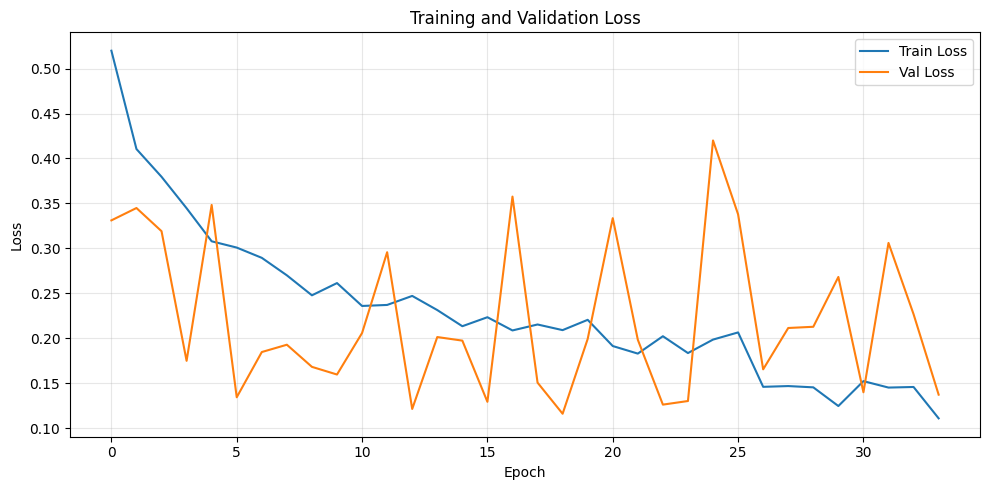

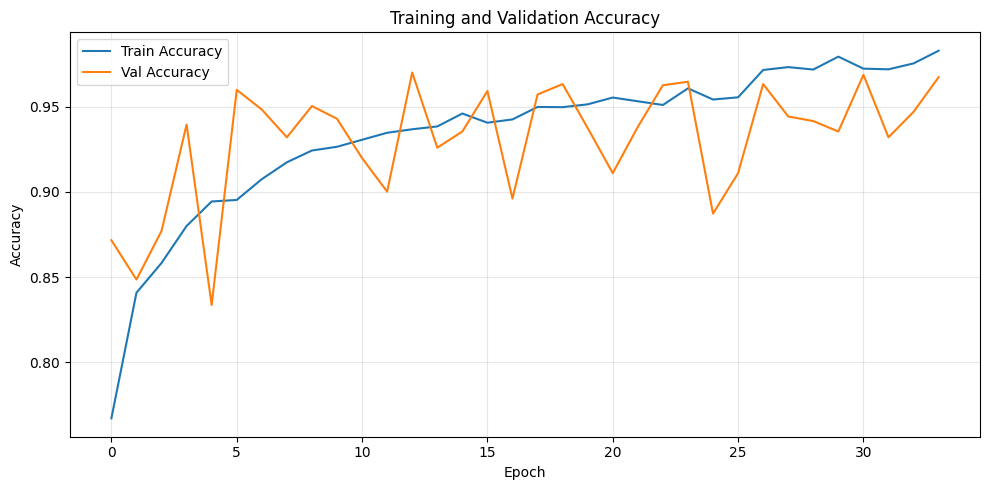

In [18]:
# ============================================================
# Cell 16 - Plot training curves
# ============================================================

def plot_training_curves(history_df, save_path):
    plt.figure(figsize=(10, 5))
    plt.plot(history_df["loss"], label="Train Loss")
    plt.plot(history_df["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path.with_name("training_loss_curve.png"), dpi=300)
    plt.show()

    if "accuracy" in history_df.columns and "val_accuracy" in history_df.columns:
        plt.figure(figsize=(10, 5))
        plt.plot(history_df["accuracy"], label="Train Accuracy")
        plt.plot(history_df["val_accuracy"], label="Val Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Training and Validation Accuracy")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(save_path.with_name("training_accuracy_curve.png"), dpi=300)
        plt.show()


plot_training_curves(history_df, FIGURES_DIR / "training_curves.png")

In [24]:
# ============================================================
# Cell 17 - Evaluasi controlled test menggunakan model di memori
# ============================================================

best_model = final_model

test_prob = best_model.predict(test_ds, verbose=VERBOSE).ravel()

test_metrics, test_pred = evaluate_binary_predictions(y_test, test_prob)

print("===== CONTROLLED TEST METRICS =====")
for k, v in test_metrics.items():
    print(f"{k}: {v:.6f}")

metrics_summary_path = REPORTS_DIR / "metrics_summary.json"
with open(metrics_summary_path, "w") as f:
    json.dump(test_metrics, f, indent=4)

print(f"Metrics summary saved to: {metrics_summary_path}")

942/942 ━━━━━━━━━━━━━━━━━━━━ 504s 534ms/step
===== CONTROLLED TEST METRICS =====
accuracy: 0.969737
precision_binary: 0.968750
recall_binary: 0.917160
f1_binary: 0.942249
macro_f1: 0.960873
balanced_accuracy: 0.953131
fall_precision: 0.968750
fall_recall: 0.917160
Metrics summary saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/reports/metrics_summary.json


===== CONFUSION MATRIX =====
[[2723   30]
 [  84  930]]


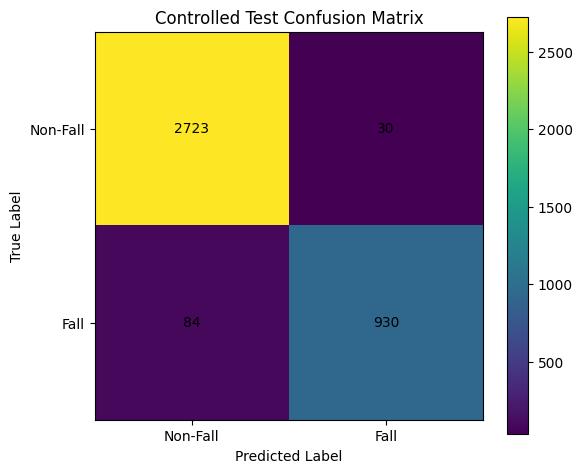

Confusion matrix saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/figures/confusion_matrix.png


,precision,recall,f1-score,support
Non-Fall,0.970075,0.989103,0.979496,2753.000000
Fall,0.968750,0.917160,0.942249,1014.000000
accuracy,0.969737,0.969737,0.969737,0.969737
macro avg,0.969412,0.953131,0.960873,3767.000000
weighted avg,0.969718,0.969737,0.969470,3767.000000


Classification report saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/reports/classification_report.csv


In [25]:
# ============================================================
# Cell 18 - Confusion matrix dan classification report
# ============================================================

cm = confusion_matrix(y_test, test_pred, labels=[0, 1])

print("===== CONFUSION MATRIX =====")
print(cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Controlled Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], CLASS_NAMES)
plt.yticks([0, 1], CLASS_NAMES)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.tight_layout()

cm_path = FIGURES_DIR / "confusion_matrix.png"
plt.savefig(cm_path, dpi=300)
plt.show()

print(f"Confusion matrix saved to: {cm_path}")

report_dict = classification_report(
    y_test,
    test_pred,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()
report_path = REPORTS_DIR / "classification_report.csv"
report_df.to_csv(report_path)

display(report_df)
print(f"Classification report saved to: {report_path}")

In [26]:
# ============================================================
# Cell 19 - Simpan test predictions
# ============================================================

test_predictions_df = meta_test_df.copy()
test_predictions_df["y_true"] = y_test
test_predictions_df["y_prob_fall"] = test_prob
test_predictions_df["y_pred"] = test_pred
test_predictions_df["true_label_name"] = test_predictions_df["y_true"].map({0: "Non-Fall", 1: "Fall"})
test_predictions_df["pred_label_name"] = test_predictions_df["y_pred"].map({0: "Non-Fall", 1: "Fall"})

predictions_path = PREDICTIONS_DIR / "test_predictions.csv"
test_predictions_df.to_csv(predictions_path, index=False)

display(test_predictions_df.head())
print(f"Test predictions saved to: {predictions_path}")

,dataset,room,activity,subject,file_id,label,start_frame,end_frame,source_path,y_true,y_prob_fall,y_pred,true_label_name,pred_label_name
0,testing,Controlled Room,Bungkuk,Kanaya,1,0,0,19,/media/spell/Spell-lab/Lidar/G.NPZ Dataset/N03...,0,0.011108,0,Non-Fall,Non-Fall
1,testing,Controlled Room,Bungkuk,Kanaya,1,0,2,21,/media/spell/Spell-lab/Lidar/G.NPZ Dataset/N03...,0,0.005769,0,Non-Fall,Non-Fall
2,testing,Controlled Room,Bungkuk,Kanaya,1,0,4,23,/media/spell/Spell-lab/Lidar/G.NPZ Dataset/N03...,0,0.003072,0,Non-Fall,Non-Fall
3,testing,Controlled Room,Bungkuk,Kanaya,1,0,6,25,/media/spell/Spell-lab/Lidar/G.NPZ Dataset/N03...,0,0.003249,0,Non-Fall,Non-Fall
4,testing,Controlled Room,Bungkuk,Kanaya,1,0,8,27,/media/spell/Spell-lab/Lidar/G.NPZ Dataset/N03...,0,0.002197,0,Non-Fall,Non-Fall


Test predictions saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/predictions/test_predictions.csv


In [27]:
# ============================================================
# Cell 20 - Per-activity error analysis
# ============================================================

activity_analysis = []

for activity, g in test_predictions_df.groupby("activity"):
    y_true_act = g["y_true"].to_numpy()
    y_pred_act = g["y_pred"].to_numpy()

    activity_analysis.append({
        "activity": activity,
        "n_windows": len(g),
        "true_label": "Fall" if LABEL_MAP[activity] == 1 else "Non-Fall",
        "accuracy": accuracy_score(y_true_act, y_pred_act),
        "fall_prediction_rate": float(np.mean(y_pred_act == 1)),
        "nonfall_prediction_rate": float(np.mean(y_pred_act == 0)),
    })

activity_analysis_df = pd.DataFrame(activity_analysis)

activity_analysis_path = REPORTS_DIR / "per_activity_error_analysis.csv"
activity_analysis_df.to_csv(activity_analysis_path, index=False)

display(activity_analysis_df)
print(f"Per-activity analysis saved to: {activity_analysis_path}")

,activity,n_windows,true_label,accuracy,fall_prediction_rate,nonfall_prediction_rate
0,Bungkuk,906,Non-Fall,0.993377,0.006623,0.993377
1,Duduk,919,Non-Fall,1.000000,0.000000,1.000000
2,Jatuh,1014,Fall,0.917160,0.917160,0.082840
3,Jongkok,928,Non-Fall,0.974138,0.025862,0.974138


Per-activity analysis saved to: /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/reports/per_activity_error_analysis.csv


In [28]:
# ============================================================
# Cell 21 - Final artifact check
# ============================================================

print("===== FINAL ARTIFACT CHECK =====")

artifact_paths = {
    "best_model": BEST_MODEL_PATH,
    "scaler": SCALER_PATH,
    "training_config": CONFIGS_DIR / "training_config.json",
    "best_hpo_config": CONFIGS_DIR / "best_hpo_config.json",
    "history": FINAL_DIR / "final_training_history.csv",
    "metrics": REPORTS_DIR / "metrics_summary.json",
    "classification_report": REPORTS_DIR / "classification_report.csv",
    "test_predictions": PREDICTIONS_DIR / "test_predictions.csv",
    "confusion_matrix": FIGURES_DIR / "confusion_matrix.png",
}

for name, path in artifact_paths.items():
    print(f"{name:25s}: {path.exists()} | {path}")

print("\nTrial root:")
print(TRIAL_ROOT)

===== FINAL ARTIFACT CHECK =====
best_model               : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/models/best_model.keras
scaler                   : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/scalers/scaler.pkl
training_config          : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/configs/training_config.json
best_hpo_config          : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/configs/best_hpo_config.json
history                  : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/final/final_training_history.csv
metrics                  : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/reports/metrics_summary.json
classification_report    : True | /media/spell/Spell-lab/Lidar/F.Training Results/DGCNN_GRU_N0369_T020_S002/reports/classification_report.csv
test_predictio